**If you lost points on the last checkpoint you can get them back by responding to TA/IA feedback**

Update/change the relevant sections where you lost those points, make sure you respond on GitHub Issues to your TA/IA to call their attention to the changes you made here.

Please update your Timeline... no battle plan survives contact with the enemy, so make sure we understand how your plans have changed.


# COGS 108 - EDA Checkpoint


# Names

- Pia Dihayco
- Asher Hardy
- Kelsie Lloyd
- Jiwoo Son
- Jason Tran


# Research Question


What systematic changes in audio characteristics (tempo, energy, instrumentalness, etc.) occur when a genre of music is adopted by separate ethnic groups, and does each culture show consistent patterns in how they modify these features?


## Background and Prior Work


Music is a form of arts and entertainment composed of sounds, both vocal and instrumental. Human beings have enjoyed music for thousands of years and it is an essential aspect of many cultures around the world. Music has a plethora of purposes, including self-expression, passing down tradition, and creating intergenerational connections. Different cultures utilize unique music styles, varying in characteristics such as instrumentation, rhythm, melody and vocals. Musical genre categorization has created a system for both artists and listeners to understand the diversity of music and shared traits within a specific genre. Intercultural interactions throughout history enabled the evolution and spread of music genres across different cultures<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1). Music genres not only retain their cultural origins but also reflect globalization, for example, K-Pop blends both Korean and Western influence<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2). However, more research to understand systematic differences in a certain music genre across cultures that have adapted it as their own.

Ethnic groups are defined as a group of people who identify with common things such as language, cultural practices, and history<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3). Unlike race, ethnicity isn't solely defined by physical traits, though ethnic groups may find commonalities in their physical features as well. Furthermore, ethnicity isn't static. Groups can change over time through means such as migration, intermarriage or globalization<a name="cite_ref-4"></a>[<sup>[4]</sup>](#cite_note-4). Thus, there's no single definite definition for what makes an ethnic group.

<a name="cite_note-1"></a>1. [^](#cite_ref-1) <a href="https://inspireculture.org/cultural-awareness/arts-culture/cross-cultural-influence-in-music-a-journey-through-genres/">https://inspireculture.org/cultural-awareness/arts-culture/cross-cultural-influence-in-music-a-journey-through-genres/</a><br>
<a name="cite_note-2"></a>2. [^](#cite_ref-2) <a href="https://aclanthology.org/2020.emnlp-main.386.pdf">https://aclanthology.org/2020.emnlp-main.386.pdf</a><br>
<a name="cite_note-3"></a>3. [^](#cite_ref-3) <a href="https://diversityresources.com/difference-between-race-ethnicity/">https://diversityresources.com/difference-between-race-ethnicity/</a><br>
<a name="cite_note-4"></a>4. [^](#cite_ref-4) <a href="https://sociology.institute/sociological-theories-concepts/defining-ethnic-groups-concepts-perspectives/#google_vignette">https://sociology.institute/sociological-theories-concepts/defining-ethnic-groups-concepts-perspectives/</a>


# Hypothesis


We hypothesize that when music genres are adopted by different ethnic groups, they will display statistically significant differences in measurable audio characteristics (i.e. tempo, energy, instrumentalness), with each ethnic group showing consistent patterns on how they modify these features. More tangibly, we predict that the subgenres will exhibit quantifiable variations in their audio measurements that correlate with the ethnic background of the artists.

This hypothesis is based on several factors. Firstly, cultural differences in musical traditions (i.e. rhythmic patterns, scale systems, instrumental preferences) are very likely to influence how artists adapt and interpret genres. Secondly, geographic/linguistic variations between ethnic groups often lead to particularly unique musical expressions, even within the same “framework” of genre (i.e. how tempo and rhythm might be modified to better accommodate different language patterns, or how traditional instruments might be incorporated into modern genres). Our hypothesis is also informed by empirical observations of how genres like hip-hop, pop, and electronic music have evolved differently across various cultural contexts, suggesting systematic patterns in how musical elements are modified to align with local musical traditions.


# Data


## Data overview

- Dataset #1
  - Dataset Name: "EveryNoise database with spotify features" (`last_fm.db`)
  - Link to the dataset: https://www.kaggle.com/datasets/cesaregarza/everynoise-database-with-spotify-features
  - Number of observations: 764,429
  - Number of variables: 2

The EveryNoise database contains comprehensive audio feature data for over 750,000 songs collected through the Spotify API, including key metrics like danceability, instrumentalness, acousticness, energy, tempo, and valence. These quantitative features serve as proxies for musical characteristics that can help differentiate between cultural interpretations of genres. The dataset also includes rich metadata about artists and genres, which will allow us to map songs to their cultural/ethnic origins by analyzing both the artist's country of origin and the cultural indicators present in genre names (e.g. "k-pop", "swedish metal").

To prepare this data for analysis, we'll most likely need to clean the genre labels to extract cultural/regional indicators (such as "korean", "swedish", "dutch", etc.), standardize artist location data, and potentially aggregate the audio features to identify patterns at the genre-culture level rather than individual song level.

The database itself is also egregiously large (approx. 600MB) which is a problem for execution times. We will most likely need to generate a subset of the data (i.e. a 10% random sample) to perform our analysis, and also convert it into a `.csv` file (instead of an SQLite database) for easier handling.


## Dataset #1: "EveryNoise database with Spotify features" (`last_fm.db`)


The blatant issue here is that the dataset is too large to even place in this GitHub repository and would need to be offshored in Git LFS. For demonstration purposes here, we will use an example SQLite database that is a 10% random sample of the full dataset (76,442 observations), and show how we would load/clean/wrangle this into a 10% random sample `.csv` file (7,644 observations). In reality, we will be simply taking a 10% random sample of the full dataset (meaning our final `.csv` would have 76,442 observations). The original dataset will not be included in this repository, but the sample dataset will be available at `data/last_fm_sample.db`, and the `.csv` file that we sampled from the real dataset (and thus will use for analysis) will be available at `data/last_fm.csv`.

We first import our necessary dependencies:


In [4]:
import sqlite3
import pandas as pd
import numpy as np

We can establish a "connection" to our SQLite database using the `sqlite3` library with `.connect()`, and load the `FEATURES_2` and `TRAINING_DB_2` tables into pandas DataFrames with `.read_sql_query()`:


In [5]:
connection = sqlite3.connect("data/last_fm_sample.db")

features_df = pd.read_sql_query("SELECT * FROM FEATURES_2", connection)
training_df = pd.read_sql_query("SELECT * FROM TRAINING_DB_2", connection)

display(features_df.head())
display(training_df.head())

,track_id,album_name,album_id,album_release_date,album_total_tracks,artist_name,artist_id,track_duration,track_name,explicit,...,key,loudness,mode,speechiness,instrumentalness,acousticness,liveness,valence,tempo,time_signature
0,2sDurGdooRkMxYRGfRvPdn,Hifalutin,4ko6ecNnYMliJ7Aon2ckdS,2019-04-12,14,Lowly,721bfjbiX9Koqt2rO8PWOY,267477,baglaens,0,...,10,-7.735,1,0.0399,0.317000,0.683000,0.1270,0.232,170.057,4
1,00iwom2ONo0LvxvRkeXQdD,Accordéons de France,3NgdAeFdTGYEsFqzqiI10O,2016-08-26,20,Karine Fontaine,5ge9YDw6vooNaGcXGKTaPn,158306,Rue Championnet,0,...,9,-2.614,1,0.0578,0.016900,0.417000,0.0822,0.822,187.702,3
2,09athuEe5kQfC7bV63jmGa,The People Tree,3OPuEGeKNwmxTfvOQJUh0Y,1993-01-01,13,Mother Earth,1v98YOkqO8vCNF8t2xUWiw,265760,Apple Green,0,...,7,-10.894,0,0.0651,0.005420,0.126000,0.1200,0.578,184.679,4
3,41s9iG3fTuu32yBnmDLCcZ,Mojo Hand,0X0Z6M1sQQpSRs9UbqpJEo,1962-04-13,9,Lightnin' Hopkins,6EZzVXM2uDRPmnHWq9yPDE,179733,Mojo Hand,0,...,11,-8.913,0,0.0640,0.000055,0.456000,0.3290,0.718,146.953,4
4,5F7gYvXfsmz6s98YOeZCvP,Poor and Infamous,08quDHgIgzN1sbHUhHsWfI,2020-09-25,12,Scumbag Millionaire,2OT0ERzAikorOYSIrRDjzA,205986,Inferno,0,...,6,-3.507,0,0.0537,0.000008,0.000008,0.3490,0.448,126.909,4


,index,track_id,genre_name
0,7,2sDurGdooRkMxYRGfRvPdn,Everything
1,14,00iwom2ONo0LvxvRkeXQdD,Everything
2,18,09athuEe5kQfC7bV63jmGa,Everything
3,24,41s9iG3fTuu32yBnmDLCcZ,Everything
4,31,5F7gYvXfsmz6s98YOeZCvP,Everything


We need to merge these two tables on `track_id` to get a single `DataFrame` with all the information we need. Since a track can have multiple genres (and thus can appear in multiple rows in the `TRAINING_DB_2` table), we'll need to aggregate the genres for each track so that each track only appears once in our merged `DataFrame`. If a track has multiple genres, they will be separated by commas in the `genre_name` column:


In [6]:
genres_combined = (
    training_df.groupby("track_id")["genre_name"]
    .agg(lambda x: ",".join(sorted(set(x))))
    .reset_index()
)

genres_combined

,track_id,genre_name
0,000gn5FEkpxkwCx42ww99y,Indie Michoacano
1,000j3FwREid2RIpm6nTLn9,Korean City Pop
2,00189pkeAMRPFPeoLgYYp7,Armenian Folk
3,001OeQOJa8lLzu37AYBt2i,Vintage Classical Singing
4,001R5qTdlCLbDvuecoMoy3,Mindfulness
...,...,...
76437,7zycbRjPCH4NHGVjM5amfq,"Celtic Harp,Harp"
76438,7zymguaCu97mWiNH4d4G3T,Minneapolis Punk
76439,7zzNyY4AnIoW9zUSkCPnED,West Australian Hip Hop
76440,7zzaZggdFuadOs0R7SuJlp,"Hard Bop,Jazz Saxophone"


We perform an inner join on `track_id` to merge the two `DataFrame`s:


In [7]:
merged_df = pd.merge(features_df, genres_combined, on="track_id", how="inner")

# For display purposes, we're showing columns that are semantic for humans:
merged_df[["track_id", "album_name", "artist_name", "genre_name"]]

,track_id,album_name,artist_name,genre_name
0,2sDurGdooRkMxYRGfRvPdn,Hifalutin,Lowly,"Aarhus Indie,Danish Indie Pop,Everything,Exper..."
1,00iwom2ONo0LvxvRkeXQdD,Accordéons de France,Karine Fontaine,"Accordéon,Everything"
2,09athuEe5kQfC7bV63jmGa,The People Tree,Mother Earth,"Acid Jazz,Everything"
3,41s9iG3fTuu32yBnmDLCcZ,Mojo Hand,Lightnin' Hopkins,"Acoustic Blues,Blues,Country Blues,Delta Blues..."
4,5F7gYvXfsmz6s98YOeZCvP,Poor and Infamous,Scumbag Millionaire,"Action Rock,Everything,Punk 'N' Roll,Swedish H..."
...,...,...,...,...
76437,3GpzybFTKLFrbGw6MYvaqQ,Xuân Hạ Thu Đông,Duong Trieu Vu,"Vietnam,Vietnam - Emerging"
76438,2cwxNwTxwTcvutGKpDBZmB,Dân Chơi Thôn,Tuấn Cry,"Vietnam,Vietnam - Emerging"
76439,3Gj1btfsYRTQ9icS0LfvAx,For You,Scenery,"Vietnam,Vietnam - Underground"
76440,5RBPhmnbILMVrHdl8pD2zp,Họ Gọi Anh Là Máy Bay Lag3,DJ Tom2k,"Vietnam,Vietnam - Underground"


Following this, we take a 10% random sample of the merged `DataFrame` and save it to a `.csv` file:


In [8]:
np.random.seed(42)

sampled_df = merged_df.sample(frac=0.1)

sampled_df.to_csv("data/last_fm_sample.csv", index=False)
# Take a look at the indices of the sampled DataFrame
sampled_df[["track_id", "album_name", "artist_name", "genre_name"]]

,track_id,album_name,artist_name,genre_name
37147,2anLSOW0qJmimTA9jWBq90,Robert Johnson,Fínix MG,"Hip Hop Tuga,Trap Tuga"
38282,6TyXeawZxBzMUq193xscwA,Kala Masala,Sahir,Indian Lo-Fi
57449,6dDBOwTKKP1VwLrlmC2UJa,Timeless Love,Love Hits On Piano,Piano Cover
53282,1Qpdc3wbQfN44u8Nl0LNPm,The Answer To Your Problems?,Marky Ramone & the Intruders,Neo-Proto
3620,7EtQeUXeYIhMBbV7uO7SKQ,Manic,Knockout Kid,"Anthem Emo,Easycore"
...,...,...,...,...
25916,17mcxzjv3w5Oz7fXXfJxxv,Dixieland Hits,Louisiana Blues Band,Dixieland
5986,1K6PKHxFILfVQfLk7ac6wa,Sister Phantom Owl Fish,Trevor Dunn's Trio Convulsant,"Avant-Rock,Laboratorio"
1550,22uAbeSGb5dh2wh3c6Akkw,Kiekies,Lucas Maree,Afrikaans
45919,6BU4THl6Q6JPSjDIpOjDqm,De NG La Banda Para Curaçao,NG La Banda,"Latin Jazz,Salsa,Timba"


For some reason there's a bunch of genres called "Everything" that are polluting the genres column. If it is one of multiple genres for a song, we'll remove it from the cell. If it is the only genre for a song, we'll remove the song from the dataset:

In [9]:
sampled_df["genre_name"] = sampled_df["genre_name"].str.replace("Everything", "")
sampled_df = sampled_df[sampled_df["genre_name"] != ""]

Our data is now ready for analysis! Here is our actual `.csv` file:


In [15]:
data = pd.read_csv("data/last_fm.csv")
data

,track_id,album_name,album_id,album_release_date,album_total_tracks,artist_name,artist_id,track_duration,track_name,explicit,...,loudness,mode,speechiness,instrumentalness,acousticness,liveness,valence,tempo,time_signature,genre_name
0,2GMSzm2ZRK4aZSVEhd1LM2,Søndermarken (Video Edit),3K2dpXIQseN96P9cRJLonX,2020-05-22,1,Henrik Lindstrand,1jdUu8RsoIhTGLeJvzoACP,250263,Søndermarken - Video Edit,0,...,-20.878,1,0.0319,0.934000,0.982000,0.1300,0.4160,152.000,4,Neo-Classical
1,5if1vlzBKrpoE1hZ6bxw2C,For You (LP),3HaUzrq7HVsuVTmIIcsZ8n,1982,7,Ago,3tr79XZgYXoRoI5G49Zqbx,353000,For You - Original Album,0,...,-5.902,1,0.0471,0.024700,0.045200,0.0377,0.9210,125.996,4,Deep Dubstep
2,3qt2gYMB8Dvi8HyI8HnrIc,Astronauta Tupy,5A1APi1ostoCgL4DgNwHU7,1997,13,Pedro Luis E A Parede,0gr5W0V12A1QsoG9lRdfQT,238933,Tudo vale a pena,0,...,-6.225,1,0.0765,0.000015,0.360000,0.1950,0.8620,145.974,4,"Brazilian Indie,Manguebeat"
3,0bEFAW0Z0KnXN8h8Uj03fh,The Garbageman and The Prostitute,2JwQqZGsKQ7ObpWZAjSkRz,2003-02-23,13,Kill Me Tomorrow,1T6PU72sainrHZrBvXvzUU,188320,Xerox My Hand,0,...,-6.009,1,0.1900,0.779000,0.000753,0.1110,0.3450,120.525,1,Experimental Indie Rock
4,4nHidfBAEfDpirZEnjfjoH,Evergreen,1LoSQuLwLBgbxO6mDk7lyY,2020-05-01,9,Bin Juice,5TkLV3WJXfWXXbG2Ka0bqa,216042,Evergreen,0,...,-10.803,0,0.0313,0.828000,0.374000,0.1070,0.0466,121.913,4,Sydney Indie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76437,75eOXZRhZza077pvj5dmK9,Swan Song,6NTVsgQI5drqf97yKLFgnJ,2020-09-11,1,Neil Mukherjee,3cR7HOfNj7hxOHFGPV6fUZ,242000,Swan Song,0,...,-20.870,1,0.0431,0.903000,0.940000,0.1120,0.4080,181.035,5,Indian Instrumental Rock
76438,7qc55PpGecCorFqxLGurp3,Opéra Puccino (Edition Collector),26iCKW9kmEhr2aRTe4Zxpx,2018-04-27,39,Oxmo Puccino,44bvfFf9VeGwVjK0QDqQ7O,250133,L'enfant seul - Remasterisé,0,...,-7.615,0,0.2300,0.000114,0.132000,0.0833,0.7340,86.983,4,"French Hip Hop,Old School Rap Français,Rap Con..."
76439,0JgwLbo5w9AGKFbnrObCXm,Refractal - EP,7tgOosMGxIXFTRz8JsXSPn,2017-11-10,6,Refractal,3LrBkTMkMyR2NVLgWlaTFW,281318,Diagonal,0,...,-7.096,0,0.0323,0.665000,0.268000,0.1040,0.3440,124.997,4,Baton Rouge Indie
76440,093BlgTCWNaweQ1lauuoda,Cayenne,4O0qb1r66362huwxkyYQ7p,2019-10-11,1,Lunar,3RoY3jJyCCFtXwAmiAlr1L,164884,Cayenne,1,...,-11.443,0,0.0891,0.000000,0.086600,0.1230,0.2940,105.031,4,Trap Funk


# Results

## Exploratory Data Analysis


### Univariate Analysis

We first start with a univariate, surface-level analysis of the data we are provided—this helps us contextualize how the dataset quantifies audio characteristics. We extract key columns into a hardcoded list `audio_features` containing numerical data, and then create a large subplot showing the distribution and mean of each column:

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "instrumentalness",
    "acousticness",
    "liveness",
    "valence",
    "tempo",
    "track_popularity",
]

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76442 entries, 0 to 76441
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            76442 non-null  object 
 1   album_name          76441 non-null  object 
 2   album_id            76442 non-null  object 
 3   album_release_date  76442 non-null  object 
 4   album_total_tracks  76442 non-null  int64  
 5   artist_name         76439 non-null  object 
 6   artist_id           76442 non-null  object 
 7   track_duration      76442 non-null  int64  
 8   track_name          76440 non-null  object 
 9   explicit            76442 non-null  int64  
 10  track_popularity    76442 non-null  int64  
 11  id                  76442 non-null  object 
 12  danceability        76442 non-null  float64
 13  energy              76442 non-null  float64
 14  key                 76442 non-null  int64  
 15  loudness            76442 non-null  float64
 16  mode

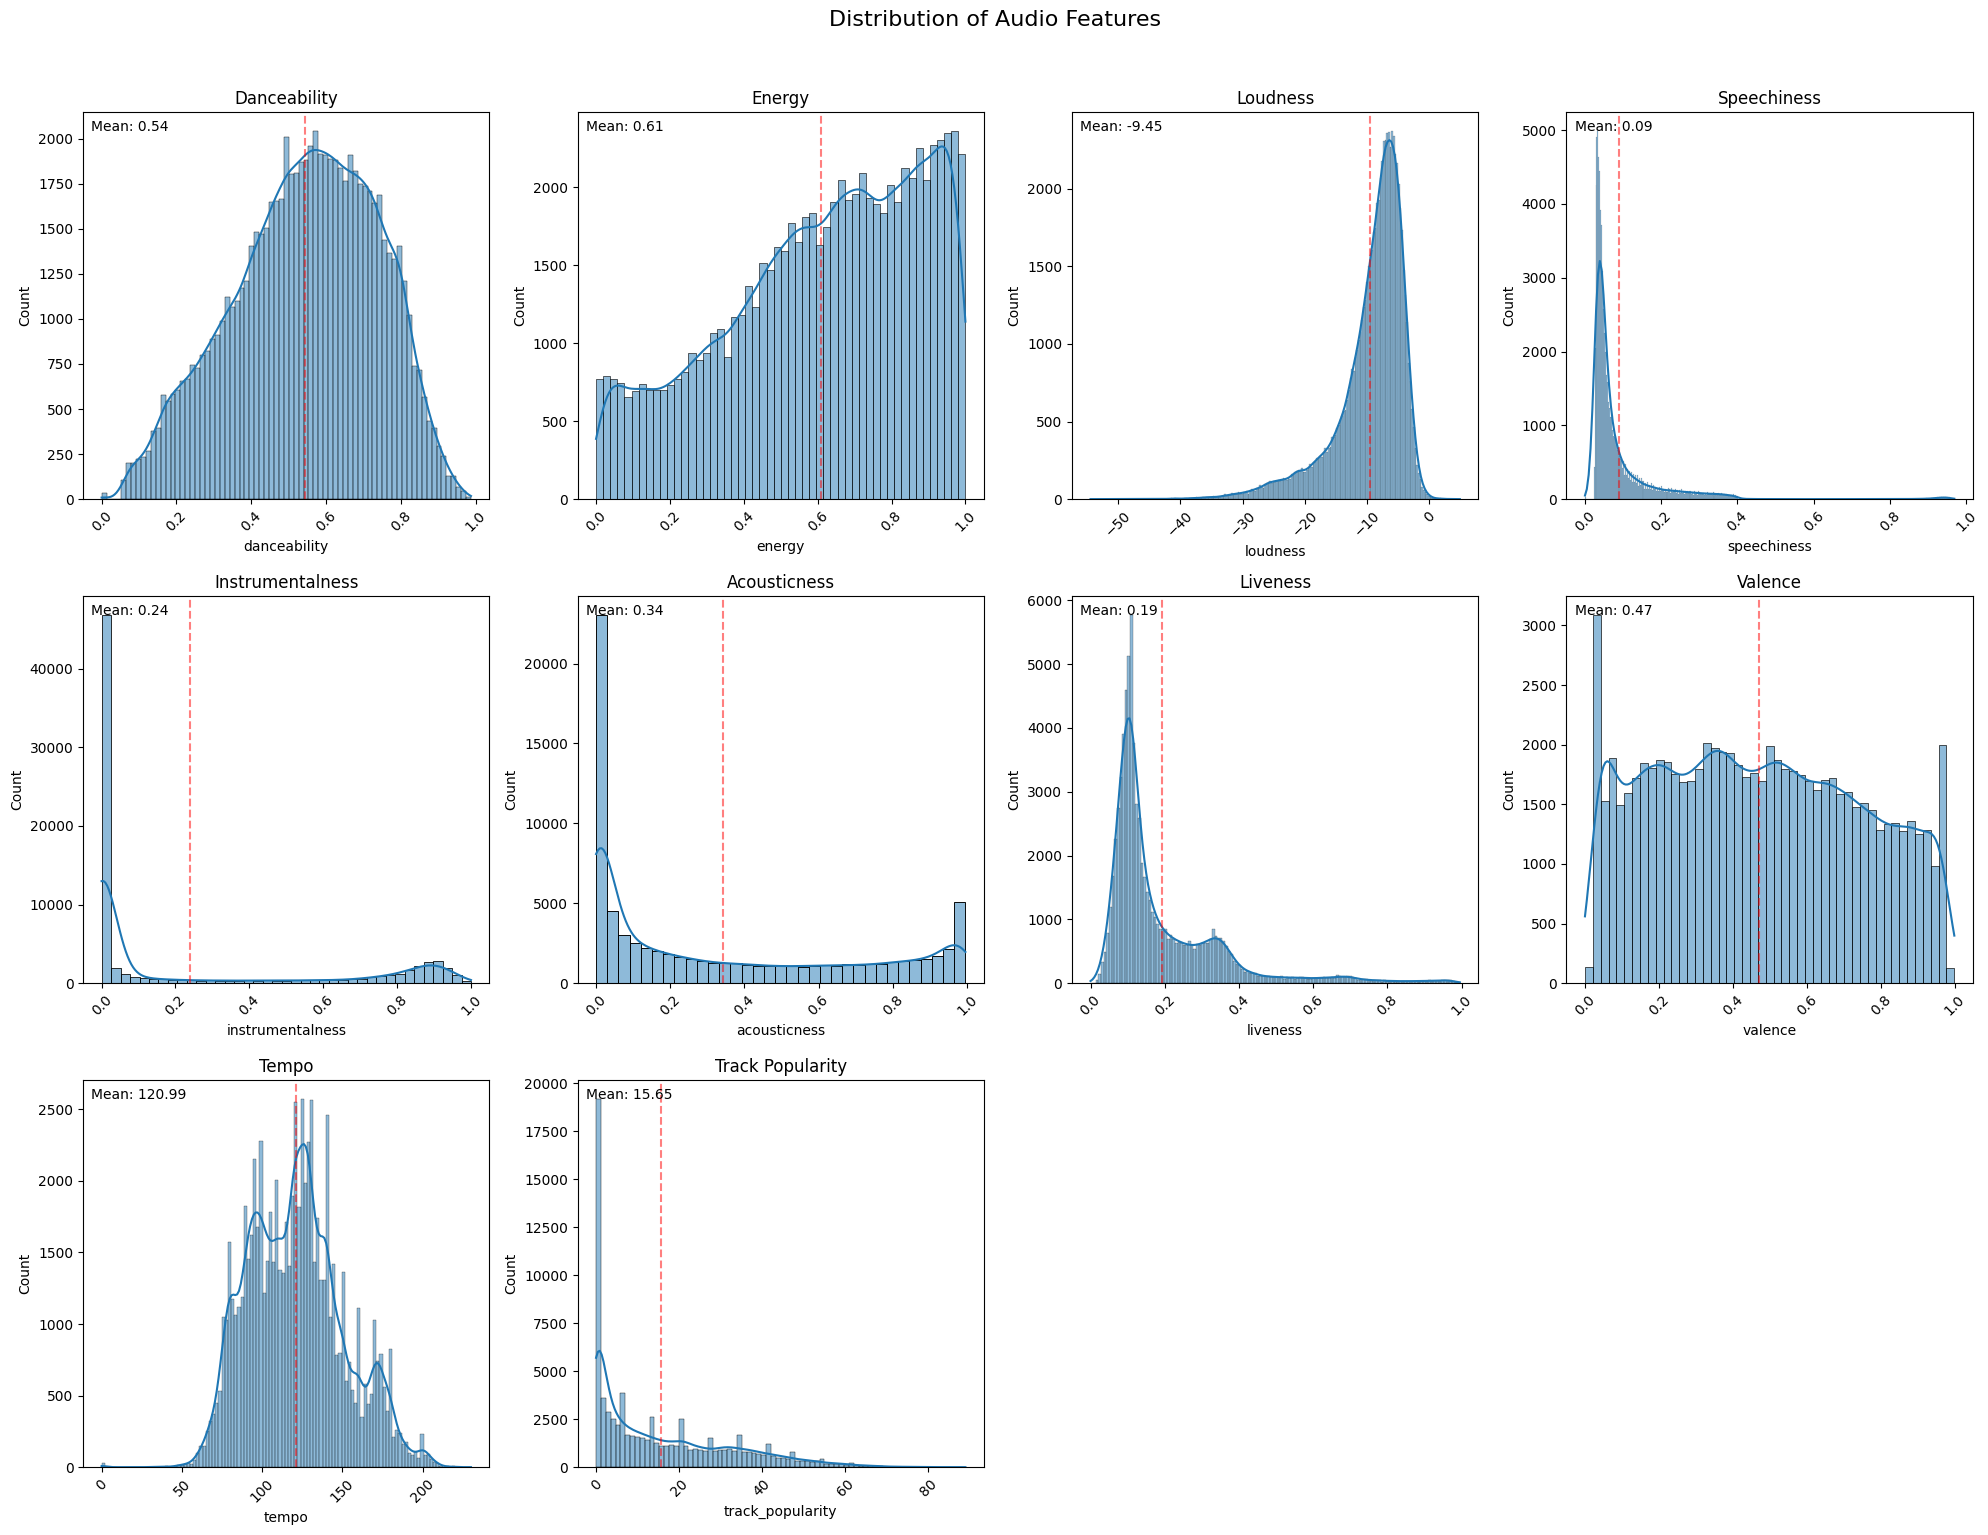

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle("Distribution of Audio Features", fontsize=16, y=1.02)
axes_flat = axes.flatten()

for idx, feature in enumerate(audio_features):
    ax = axes_flat[idx]

    sns.histplot(data=data, x=feature, kde=True, ax=ax)

    mean_val = data[feature].mean()
    ax.axvline(mean_val, color="red", linestyle="--", alpha=0.5)
    ax.text(0.02, 0.98, f"Mean: {mean_val:.2f}", transform=ax.transAxes, va="top")

    ax.set_title(f'{feature.replace("_", " ").title()}')
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(audio_features), len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

This subplot helps display what amount of each characteristic is common within our dataset.

- **Danceability** indicates that most songs fall within the middle and create a mostly-normal distribution to highlight that most songs are semi-danceable and the extremes are either not danceable at all or completely danceable.

- **Energy** of songs features a mostly linear correlation between the count of songs and their energy, with songs leaning more towards higher energy. This is in line with the idea that our songs are randomly sampled and should have a mean somewhere in the middle values to represent a diverse data set.

- The **loudness** graph indicates that most songs hover around a certain loudness and skew left from the peak, showcasing how most music is mastered at a certain volume and stays within a certain loudness. The quieter songs are either generally softer in totality or just under mastered to a certain loudness.

- Our **speechiness** data indicates that most of our songs feature very little to none spoken word and are mostly singing and instrumental. It also shows that if songs do have spoken word, it isn’t any more than 40% of the song, meaning we don’t have any spoken word pieces.

- **Acousticness** highlights how songs can either be fully acoustic or fully non-acoustic with most songs being a mix of both. This makes sense because there are songs with only acoustic instruments such as folk and songs with no acoustic instruments such as EDM. Most songs fall more towards less acoustic-ness because of the larger amount of virtual and electronic instruments that exist and their wider genre appeal.

- The **liveness** graph shows that most songs have a low liveness value which correlates with how most songs are recorded in a studio with a less-live setup. Since every song is performed at least a little bit live (recording takes), the graph has very little 0 counts but averages around the 0.1 mark.

- **Valence** indicates how happy/sad our songs are with there being a clear range from “sad” to “happy” songs. We can see that while the average song is somewhere between the two valences, there are also plenty of songs that are completely extreme with either a totally 0 or totally 1 valence.

- Our **tempo** data makes sense as we see songs fall within 80 to 160 bpm with some outliers. Those outliers are typically from very mellow genres such as ambient music and extreme genres like thrash metal.

- **Track popularity** illustrates how most songs are not popular at all with a skew right indicating how less songs are popular than not. This makes sense as we expect randomly sorted songs to include some that are extremely unknown and barely any that are famous. The massive dropoff from 0 to the next integer shows how rare known music is in actuality.


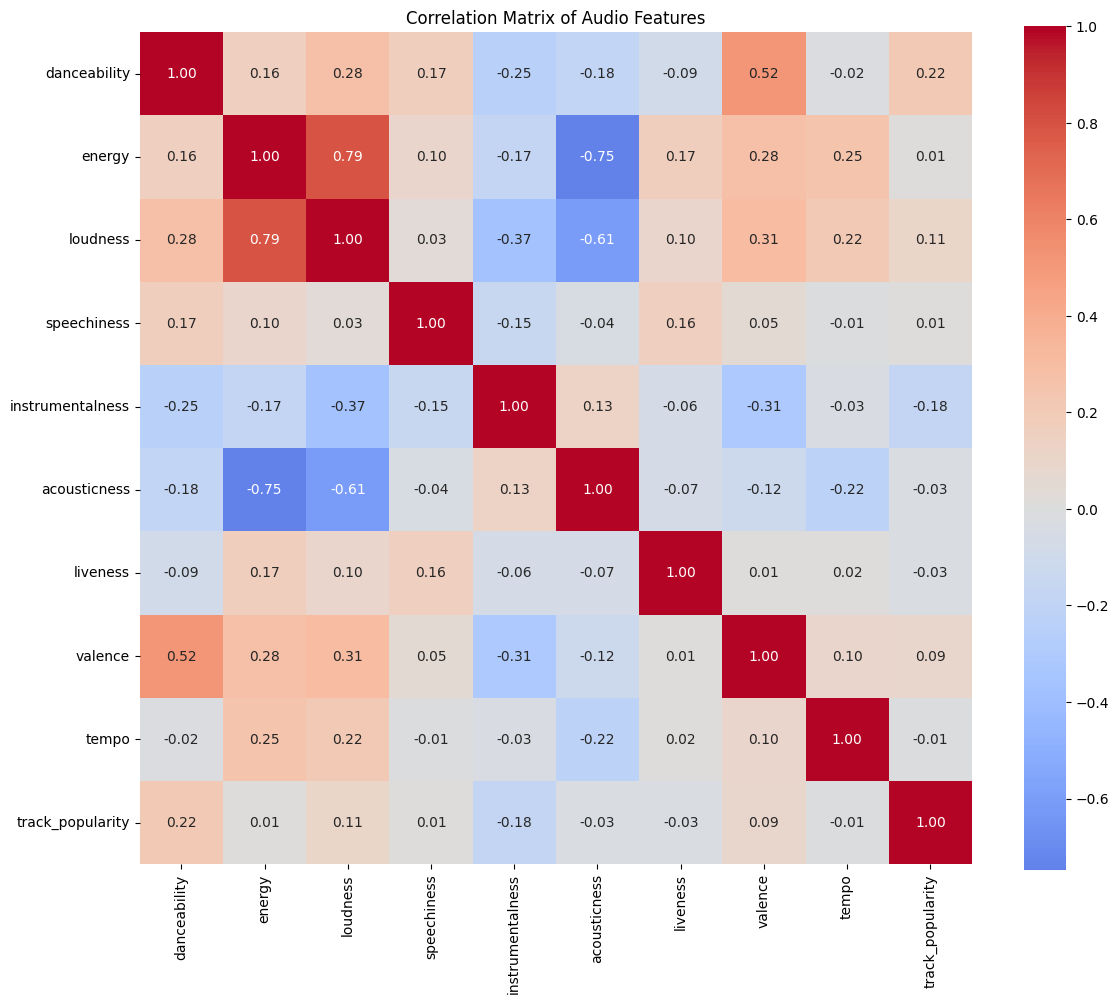


Strongest Correlations:
-----------------------
energy vs. loudness: 0.789
energy vs. acousticness: -0.748
loudness vs. acousticness: -0.608
danceability vs. valence: 0.516
loudness vs. instrumentalness: -0.366
instrumentalness vs. valence: -0.313
loudness vs. valence: 0.310


In [13]:
plt.figure(figsize=(12, 10))
correlation_matrix = data[audio_features].corr()

sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True
)
plt.title("Correlation Matrix of Audio Features")
plt.tight_layout()
plt.show()

print("\nStrongest Correlations:")
print("-----------------------")
correlations = []
for i in range(len(audio_features)):
    for j in range(i + 1, len(audio_features)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.3:  # threshold for "strong" correlation
            correlations.append((audio_features[i], audio_features[j], corr))

for feat1, feat2, corr in sorted(correlations, key=lambda x: abs(x[2]), reverse=True):
    print(f"{feat1} vs. {feat2}: {corr:.3f}")

The heatmap above allows us to visualize the correlation matrix between multiple audio characteristics using colors and a pairwise correlation coefficient, $r$, which can range from -1.00 to +1.00. Positive correlations are highlighted in warm tones, and negative relationships are highlighted in cool tones. For our project, correlations exceeding the absolute coefficient value of 0.3 are considered a "strong correlation." A more red square and a higher positive coefficient value indicates a stronger positive correlation between two audio characteristics. A more blue square and a lower negative coefficient value indicates a stronger negative correlationship between two audio characteristics. A more grey square and coefficient value of 0.00 means no correlation between two audio characteristics.

As expected, diagonal audio characteristics have a correlation coefficient of +1.00 (They have a perfect correlation with themselves).

The strongest positive correlation between two audio characteristics is energy vs. loudness, which has a correlation coefficient of +0.789. This means:
- As the energy of a song increases, its loudness tends to also increase.

On the other hand, the strongest negative correlation between two audio characteristics is energy vs. acousticness, with a correlation coefficient of -0.748. This means:
- As the energy of a song increases, its acousticness tends to decrease.

There is moderately strong positive correlation between danceability vs. valence with a correlation coefficient of 0.516 and between loudness vs. valence with a correlation with a correlation of 0.310. This means:
- As the danceability of a song increases, its valence tends to increase.
- As the loudness of a song increases, its valence also tends to increase.

There is a moderately strong negative correlation between loudness vs. acousticness with a correlation coefficient of -0.608, between loudness vs. instrumentalness with a correlation coefficient of -0.366, and between instrumentalness vs. valence with a correlation coefficient of -0.313. This means:
- As the loudness of a song increases, its acousticness tends to decrease.
- As the loudness of a song increases, its instrumentalness tends to decrease.
- As the instrumentalness of a song increases, its valence tends to decrease.

Audio characteristics with near-zero correlation coefficients (e.g. speechiness and tempo) have an extremely weak linear relationship.

C:\Users\Jason\AppData\Local\Temp\ipykernel_16628\601279317.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


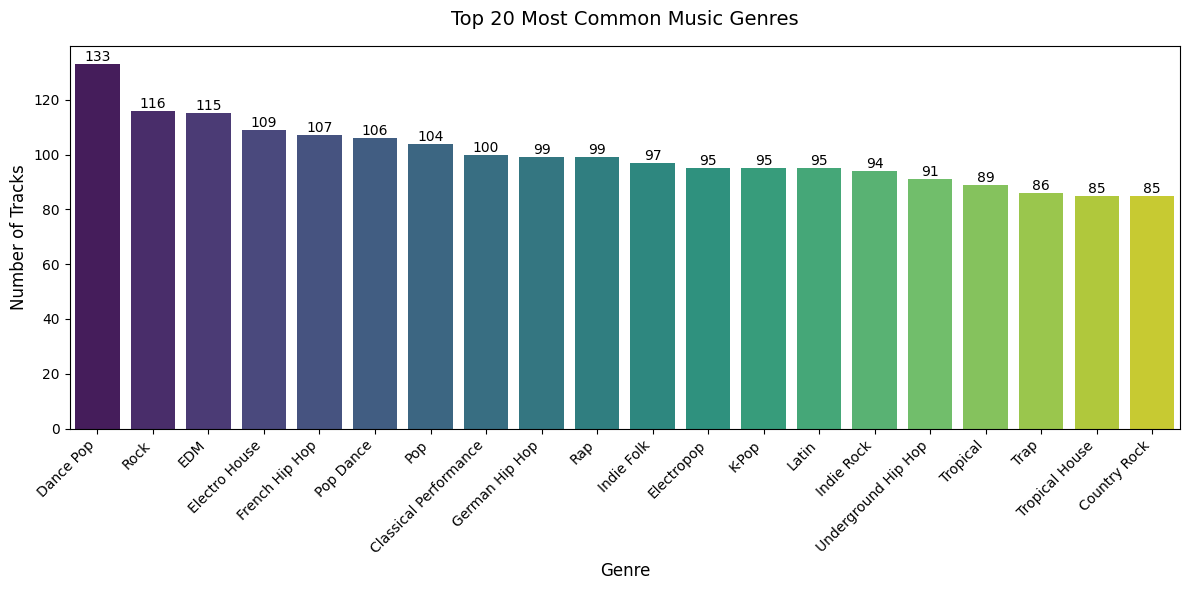

In [14]:
genre_counts = (
    data['genre_name']
    .str.split(',')
    .explode()
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

plt.title('Top 20 Most Common Music Genres', fontsize=14, pad=15)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Tracks', fontsize=12)

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(genre_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

The above chart displays the top 20 most common genres within the dataset. Something very notable about this chart is the recurring amount of genres that make use of electronic music and instruments, specifically **'dance pop'**, **'EDM'**, **'pop dance'**, **'electropop'**, and **'tropical house'**. Furthermore, the ratio of electronic genres seems to be more common compared to other umbrella genres like rock and hip-hop.

* This info further supports the distribution graphs above, specifically the graphs about 'acousticness' and 'danceability'. As noted earlier, most songs fall towards less use of acoustics given the larger variety of electronic and virtual instruments, and, most relevant, "wider genre appeal".

* As for the distribution chart about 'danceability', whereas the chart seems to find that most songs fall in between extremely non-danceable and extremely danceable, the slope leans closer to the danceable extreme. This too is reflected in the 20 most common genres above not just in the recurring amounts of genres under the electronic umbrella, but also other notably upbeat genres such as **'pop'**, **'K-pop'** and **'Latin'**. Of course, it could also be argued that this overall balance between non-danceable and very danceable is also reflected in how other common genres are very much also ones that aren't as known to be danceable, such as **'hip-hop'**, **'classical performance'** and **'rock'**.

* The distribution graph about 'energy' can also be connected to our top 20 chart. As stated earlier, the original chart about energy has an overall positive linear correlation between the amount of songs and energy. While there are significant outliers such as **'classical performance'** and **'indie folk'**, nearly every genre on this list is some form of energetic.

* 'Valence', or rather the balance between overall happy and sad moods, is also reflected in this whole list of genres. In general, most of these genres like **'pop'**, **'rock'**, and **'hip-hop'** have their fair share of happy and sad songs. That said, notice also how genres that have more of a reputation for aggressive or sad moods such as metal or ambience aren't within the list, even despite how both often fall under the 'rock' and 'electronic' umbrellas respecitvely.

* The exact same observations could also be applied to how our genre chart connects to our 'tempo' distribution chart. In general, there seems to be a preference for songs with the average tempo noted above. Again, notice how whereas there is a wide preference for very energetic, pretty danceable songs, genres on both extremes of tempo like, once again, metal and ambience, don't appear on the genre chart. Thus, this too reflects the overall preference for tempos between 80 bpm and 160 bpm, any and all of which can be found in **'electronic'**, **'rock'**, **'pop'** and **'hip-hop'** genres easily.

# Ethics & Privacy


Our analysis of music characteristics across cultural boundaries presents several important ethical considerations that we must address before and throughout the research process.

While Spotify's API provides rich data, we acknowledge that there are potential issues with particular data collection methods and usage rights. We recognize that using Spotify as our primary data source introduces inherent sampling bias, as Spotify’s availability and adoption varies significantly across different regions and demographics (i.e. skewing the data towards more developed geographic regions, or skewing away from geographic regions that use a platform other than Spotify mainly).
Another ethical consideration in our study is the fair/respectful representation of different cultural groups. There are several potential challenges here:

- The risk of oversimplification/overgeneralization when categorizing music by ethnic or cultural groups
- Potential microaggressions in the process of cultural classification
- Uneven representation of different regions and ethnic groups in our dataset
- Accurately representing multicultural influences in music is difficult

While some limitations are inherent to our data source and cannot be fully resolved, we will take measures to address them. In terms of the data itself, we will follow Spotify’s terms of service strictly and be transparent about data limitations in our analysis. For cultural representation, we will use respectful, clear criteria for cultural categorization while acknowledging that our categories are simplifications and assigned arbitrarily. These steps are not perfect, but will ensure our research is conducted and presented responsibly with clear acknowledgment of its limitations/scope.


# Team Expectations


- Team will meet weekly on Tuesdays at 9:30 PM via Zoom for project coordination and updates
- In-person meetings will be scheduled as needed for intensive collaboration phases
- All members will respond to Instagram group chat messages within 12 hours
- Members must notify the team in advance if unable to attend meetings
- If a member misses a meeting, they will take on additional tasks before the next meeting to maintain fair workload
- All members will complete assigned tasks by agreed deadlines
- Each member will inform the team early if they need help or anticipate delays with their tasks


# Project Timeline Proposal


| Meeting Date | Meeting Time    | Completed Before Meeting                                                                     | Discuss at Meeting                                                                                                                      |
| ------------ | --------------- | -------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| 10/29        | 9:30 PM         | Read project requirements, Begin background research, Look into potential datasets           | Determine communication channels, Discuss and finalize research question, Draft initial hypothesis, Assign background research sections |
| 11/5         | 9:30 PM         | Complete background research sections, Initial data exploration, Draft ethics considerations | Review and compile background research, Finalize dataset choice, Plan data cleaning approach, Divide Checkpoint 1 tasks                 |
| 11/12        | 9:30 PM         | Individual data cleaning tasks, Draft data cleaning documentation                            | Final review of Checkpoint 1, Submit Checkpoint 1 (due 11/13), Plan EDA approach, Assign EDA tasks                                      |
| 11/19        | 9:30 PM         | Individual EDA tasks, Initial visualizations, Preliminary analysis                           | Review EDA progress, Refine visualizations, Plan remaining analysis, Divide remaining Checkpoint 2 tasks                                |
| 11/26        | 9:30 PM         | Complete assigned EDA sections, Refine analysis                                              | Final review of Checkpoint 2, Submit Checkpoint 2 (due 11/27), Plan final analysis and video                                            |
| 12/3         | 9:30 PM         | Complete analysis sections, Draft conclusions, Initial video outline                         | Review full project, Finalize analysis, Plan video production, Assign final tasks                                                       |
| 12/10        | 9:30 PM         | Complete all assigned sections, Draft video components                                       | Final project review, Complete video, Prepare for submission                                                                            |
| 12/11        | Before 11:59 PM | Final edits                                                                                  | Submit final project, Submit video, Complete surveys                                                                                    |
